# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Loading the Dataset

In [2]:
df = pd.read_csv("bitcoin.csv")

# Viewing the first 5 rows of the dataset
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [3]:
# Viewing the columns of the dataset
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Now that we have viewed the first five rows and the column names of the dataset, we shall now check for any null values in the dataset using the `info()` method on the DataFrame `df`.

In [4]:
# Checking for null values in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


Let us also view the descriptive statistics of the dataset using the `describe` method.

In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


# Data Preprocessing

## Checking for Null Values

We shall now check for how many missing values or null values are present in the dataset.

In [6]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [7]:
type(df['Date'][0])

str

## Converting date columns to `DateTime` format

Currently, the 'Date' column is in string format. We need to convert it into `DateTime` format in order to do further data analysis and model training on the dataset. The conversion of the date columns to `DateTime` format is shown below:

In [8]:
# Converting the date columns to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

,Date
0,2014-09-17
1,2014-09-18
2,2014-09-19
3,2014-09-20
4,2014-09-21
...,...
2708,2022-02-15
2709,2022-02-16
2710,2022-02-17
2711,2022-02-18


In [9]:
# Verifying the conversion to datetime format
type(df['Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

## Setting the 'Date' column as index

In [10]:
# Setting the date column as index
df = df.set_index('Date')

# Viewing the first five rows after setting the index
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## Normalizing Numerical Features

Now, using the `MinMaxScaler` from the Scikit-Learn library, we shall normalize the remaining numeric features of the dataset.

In [11]:
# Importing MinMaxScaler from sklearn library
from sklearn.preprocessing import MinMaxScaler

# Creating an instance of MinMaxScaler
scaler = MinMaxScaler()

# Fitting and transforming the dataset in a single step
scaled_dataset = scaler.fit_transform(df)

# Viewing the first few rows of the normalized dataset
scaled_dataset

array([[4.28907290e-03, 3.73944128e-03, 4.24270741e-03, 4.14358659e-03,
        4.14358659e-03, 4.31449241e-05],
       [4.15542811e-03, 3.57446063e-03, 3.64887469e-03, 3.65546320e-03,
        3.65546320e-03, 8.14009147e-05],
       [3.66922344e-03, 3.15121937e-03, 3.21734240e-03, 3.21556748e-03,
        3.21556748e-03, 9.11925723e-05],
       ...,
       [6.49522493e-01, 6.40457720e-01, 6.05309268e-01, 5.98911890e-01,
        5.98911890e-01, 7.47680553e-02],
       [5.99280621e-01, 5.93739746e-01, 5.96069746e-01, 5.91387854e-01,
        5.91387854e-01, 6.64006113e-02],
       [5.91413949e-01, 5.83778445e-01, 6.01707065e-01, 5.92804310e-01,
        5.92804310e-01, 6.34199255e-02]])

In [12]:
df.columns, df.index

(Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object'),
 DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
                '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
                '2014-09-25', '2014-09-26',
                ...
                '2022-02-10', '2022-02-11', '2022-02-12', '2022-02-13',
                '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17',
                '2022-02-18', '2022-02-19'],
               dtype='datetime64[ns]', name='Date', length=2713, freq=None))

In order to read and interpret the data better, we shall load the scaled dataset into another Pandas DataFrame.

In [13]:
# Loading the scaled dataset into a DataFrame
scaled_df = pd.DataFrame(scaled_dataset, index = df.index, columns = df.columns)

# Viewing the first five rows of the new DataFrame
scaled_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,0.004289,0.003739,0.004243,0.004144,0.004144,0.000043
2014-09-18,0.004155,0.003574,0.003649,0.003655,0.003655,0.000081
2014-09-19,0.003669,0.003151,0.003217,0.003216,0.003216,0.000091
2014-09-20,0.003232,0.003085,0.003298,0.003425,0.003425,0.000088
2014-09-21,0.003431,0.002927,0.003348,0.003275,0.003275,0.000059


## Feature Engineering

We shall now engineer some more features in from the scaled dataset in order to make better predictions.

In [14]:
scaled_df['SMA_50'] = scaled_df['Close'].rolling(window=50).mean()  # 50-day SMA
scaled_df['SMA_200'] = scaled_df['Close'].rolling(window=200).mean()  # 200-day SMA

In [15]:
# Calculate 12-day EMA
scaled_df['EMA_12'] = scaled_df['Close'].ewm(span=12, adjust=False).mean()

# Calculate 26-day EMA
scaled_df['EMA_26'] = scaled_df['Close'].ewm(span=26, adjust=False).mean()

In [16]:
# Calculate the middle band (SMA of 20 days)
scaled_df['Bollinger_Middle'] = scaled_df['Close'].rolling(window=20).mean()

# Calculate the rolling standard deviation (20-day window)
scaled_df['Bollinger_Std'] = scaled_df['Close'].rolling(window=20).std()

# Calculate the upper and lower Bollinger Bands
scaled_df['Bollinger_Upper'] = scaled_df['Bollinger_Middle'] + (2 * scaled_df['Bollinger_Std'])
scaled_df['Bollinger_Lower'] = scaled_df['Bollinger_Middle'] - (2 * scaled_df['Bollinger_Std'])


In [17]:
# Step 1: Calculate daily price change
scaled_df['Delta'] = scaled_df['Close'].diff()

# Step 2: Separate gains and losses
scaled_df['Gain'] = scaled_df['Delta'].where(scaled_df['Delta'] > 0, 0)
scaled_df['Loss'] = -scaled_df['Delta'].where(scaled_df['Delta'] < 0, 0)

# Step 3: Calculate the average gain and average loss over a 14-day period
scaled_df['Avg_Gain'] = scaled_df['Gain'].rolling(window=14).mean()
scaled_df['Avg_Loss'] = scaled_df['Loss'].rolling(window=14).mean()

# Step 4: Calculate the Relative Strength (RS)
scaled_df['RS'] = scaled_df['Avg_Gain'] / scaled_df['Avg_Loss']

# Step 5: Calculate the RSI using the formula RSI = 100 - (100 / (1 + RS))
scaled_df['RSI'] = 100 - (100 / (1 + scaled_df['RS']))

# Optional: Drop intermediate columns to clean up the DataFrame
scaled_df = scaled_df.drop(columns=['Delta', 'Gain', 'Loss', 'Avg_Gain', 'Avg_Loss', 'RS'])


In [18]:
scaled_df.head()

,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,EMA_12,EMA_26,Bollinger_Middle,Bollinger_Std,Bollinger_Upper,Bollinger_Lower,RSI
Date,,,,,,,,,,,,,,,
2014-09-17,0.004289,0.003739,0.004243,0.004144,0.004144,0.000043,NaN,NaN,0.004144,0.004144,NaN,NaN,NaN,NaN,NaN
2014-09-18,0.004155,0.003574,0.003649,0.003655,0.003655,0.000081,NaN,NaN,0.004068,0.004107,NaN,NaN,NaN,NaN,NaN
2014-09-19,0.003669,0.003151,0.003217,0.003216,0.003216,0.000091,NaN,NaN,0.003937,0.004041,NaN,NaN,NaN,NaN,NaN
2014-09-20,0.003232,0.003085,0.003298,0.003425,0.003425,0.000088,NaN,NaN,0.003858,0.003996,NaN,NaN,NaN,NaN,NaN
2014-09-21,0.003431,0.002927,0.003348,0.003275,0.003275,0.000059,NaN,NaN,0.003769,0.003942,NaN,NaN,NaN,NaN,NaN


We will have to check for how many null values are present in our dataset before we train our model on it.

In [19]:
scaled_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
SMA_50,49
SMA_200,199
EMA_12,0
EMA_26,0


Clearly, we have null values for features such as `SMA_200`, `SMA_50`, `Bollinger_Middle`, `Bollinger_Std` and others. We will have to fill these null values. We will use the `bfill` method as shown below:

In [20]:
# scaled_df.fillna(method='bfill', inplace=True)
scaled_df.bfill(inplace=True)
scaled_df.head()

,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,EMA_12,EMA_26,Bollinger_Middle,Bollinger_Std,Bollinger_Upper,Bollinger_Lower,RSI
Date,,,,,,,,,,,,,,,
2014-09-17,0.004289,0.003739,0.004243,0.004144,0.004144,0.000043,0.002889,0.00197,0.004144,0.004144,0.003143,0.000528,0.004198,0.002088,31.997433
2014-09-18,0.004155,0.003574,0.003649,0.003655,0.003655,0.000081,0.002889,0.00197,0.004068,0.004107,0.003143,0.000528,0.004198,0.002088,31.997433
2014-09-19,0.003669,0.003151,0.003217,0.003216,0.003216,0.000091,0.002889,0.00197,0.003937,0.004041,0.003143,0.000528,0.004198,0.002088,31.997433
2014-09-20,0.003232,0.003085,0.003298,0.003425,0.003425,0.000088,0.002889,0.00197,0.003858,0.003996,0.003143,0.000528,0.004198,0.002088,31.997433
2014-09-21,0.003431,0.002927,0.003348,0.003275,0.003275,0.000059,0.002889,0.00197,0.003769,0.003942,0.003143,0.000528,0.004198,0.002088,31.997433


In [21]:
X, y = scaled_df.drop(['Close'], axis=1), scaled_df['Close']
X.shape, y.shape

((2713, 14), (2713,))

## Splitting the Dataset

To avoid data snooping bias, we will have to split our dataset into train and test dataset. After doing so, we will have to use the train set to train our model, and evaluate its performance on the test dataset.

In [22]:
from sklearn.model_selection import train_test_split

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2170, 14), (2170,), (543, 14), (543,))

# Exploratory Data Analysis

Here, we will first analyze the price trends over time using visualization tools such as line plots. Next, we will create a correlation heatmap to identify correlations between different features.

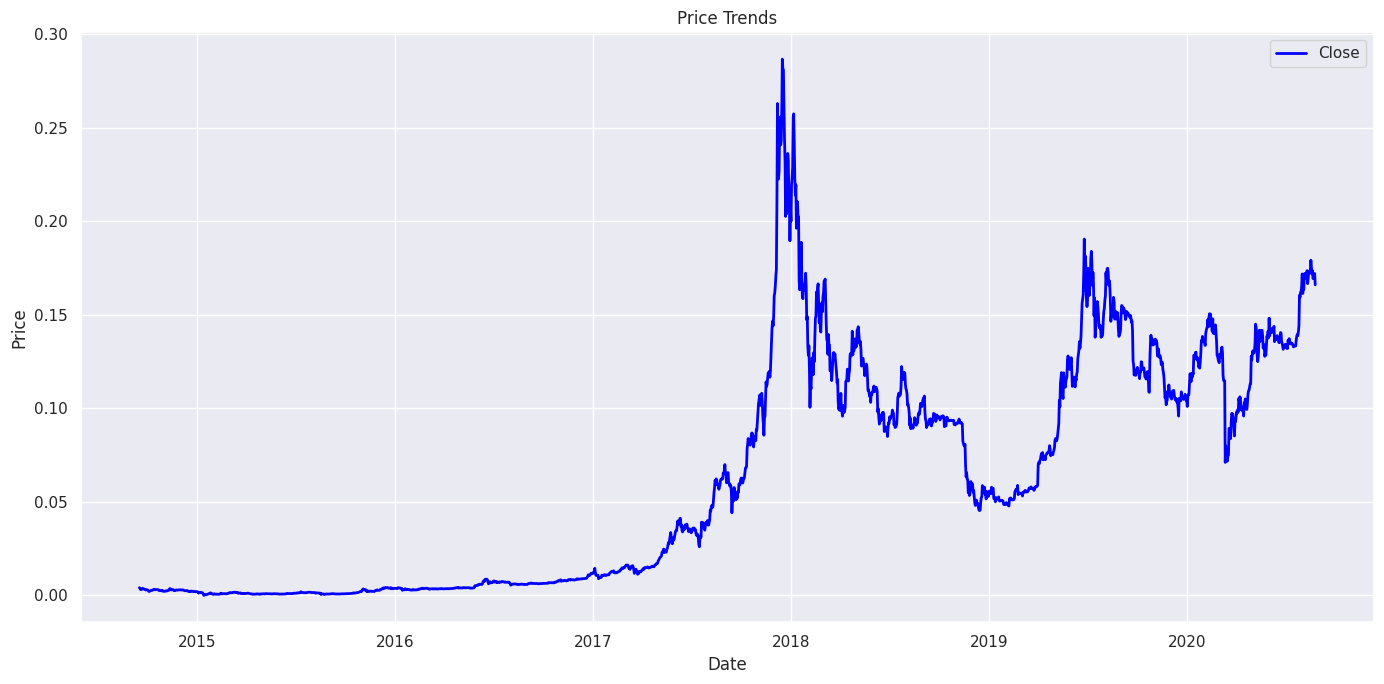

In [23]:
# Ensure the index is datetime (if not already)
X_train.index = pd.to_datetime(X_train.index)

# Set the figure size
plt.figure(figsize=(14, 7))

# Plot prices against time
plt.plot(X_train.index, y_train, label='Close', color='blue', linewidth=2)

# Add title and labels
plt.title('Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

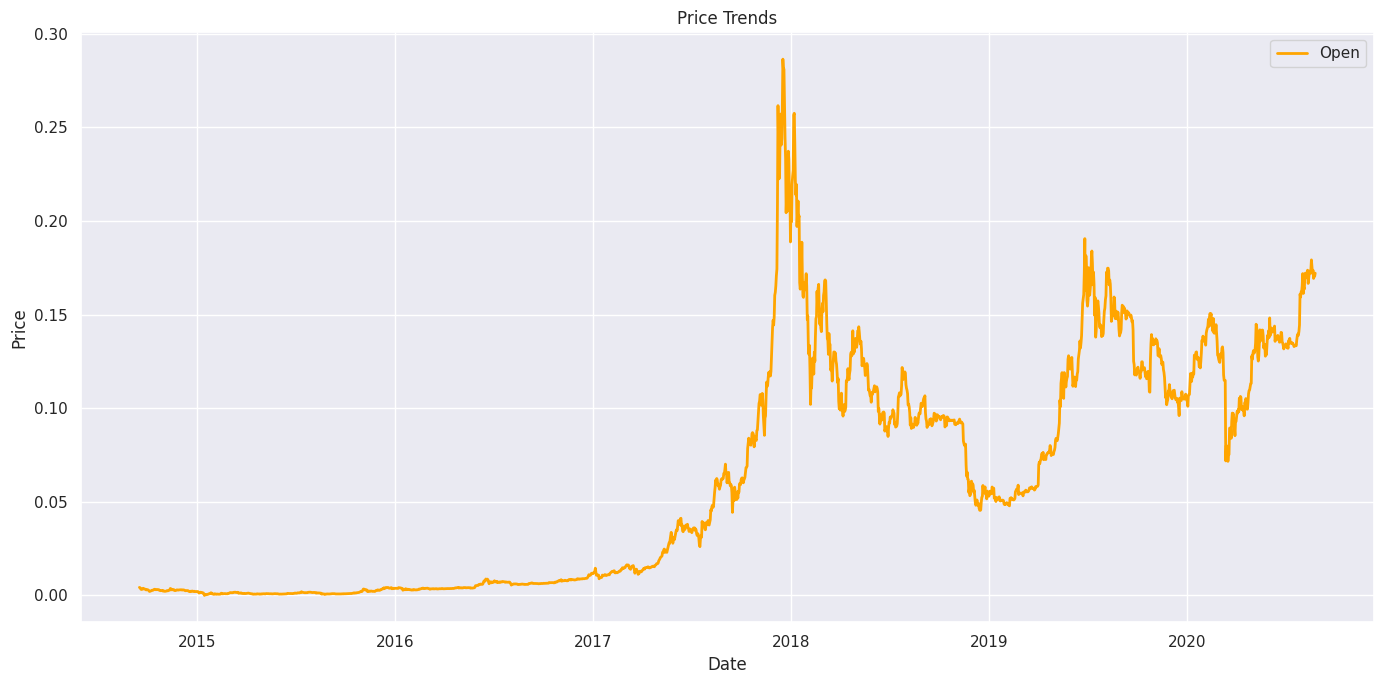

In [24]:
# Set the figure size
plt.figure(figsize=(14, 7))

# Plot prices against time
plt.plot(X_train.index, X_train['Open'], label='Open', color='orange', linewidth=2)

# Add title and labels
plt.title('Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

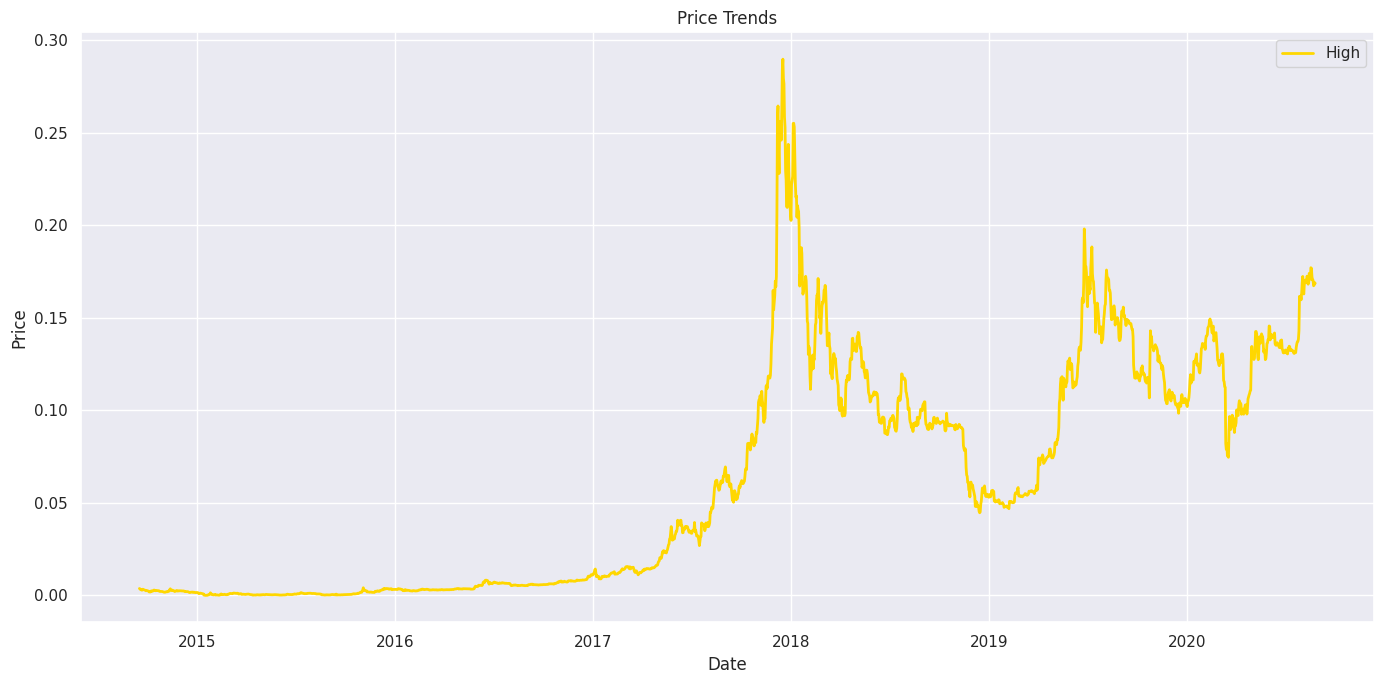

In [25]:
# Set the figure size
plt.figure(figsize=(14, 7))

# Plot prices against time
plt.plot(X_train.index, X_train['High'], label='High', color='gold', linewidth=2)

# Add title and labels
plt.title('Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

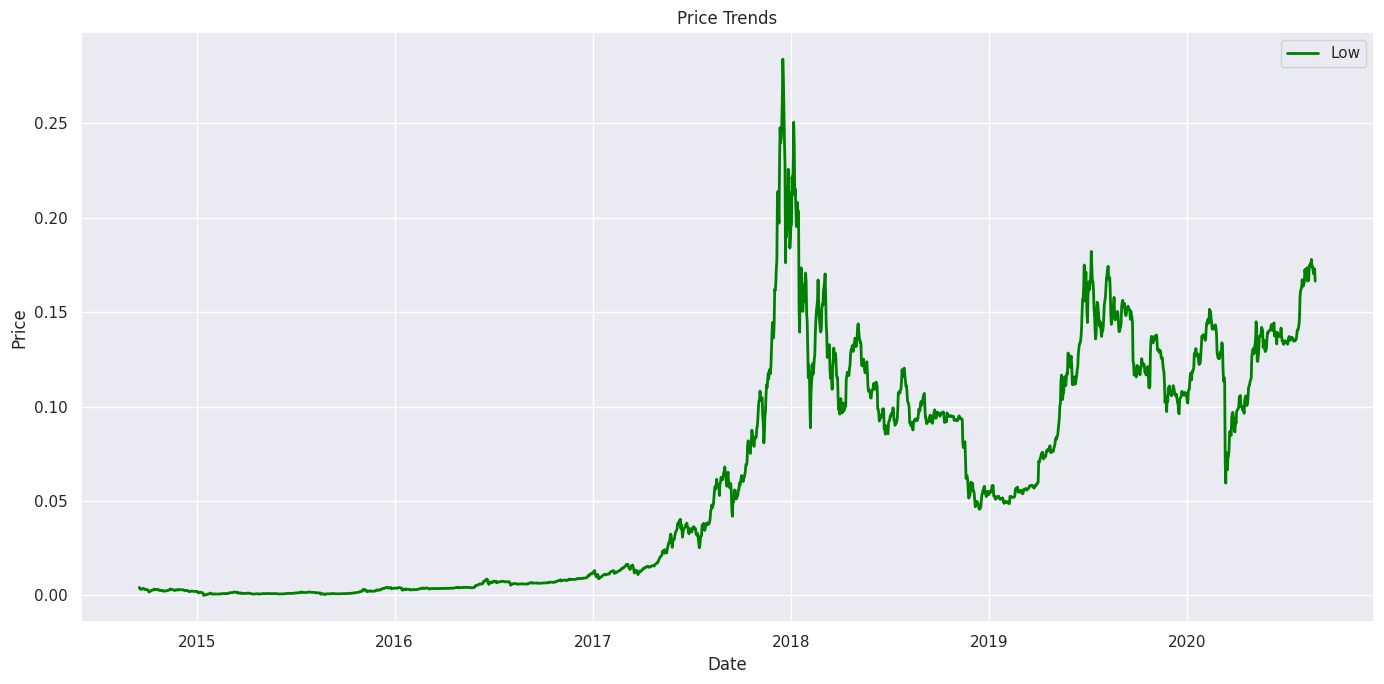

In [26]:
# Set the figure size
plt.figure(figsize=(14, 7))

# Plot prices against time
plt.plot(X_train.index, X_train['Low'], label='Low', color='green', linewidth=2)

# Add title and labels
plt.title('Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

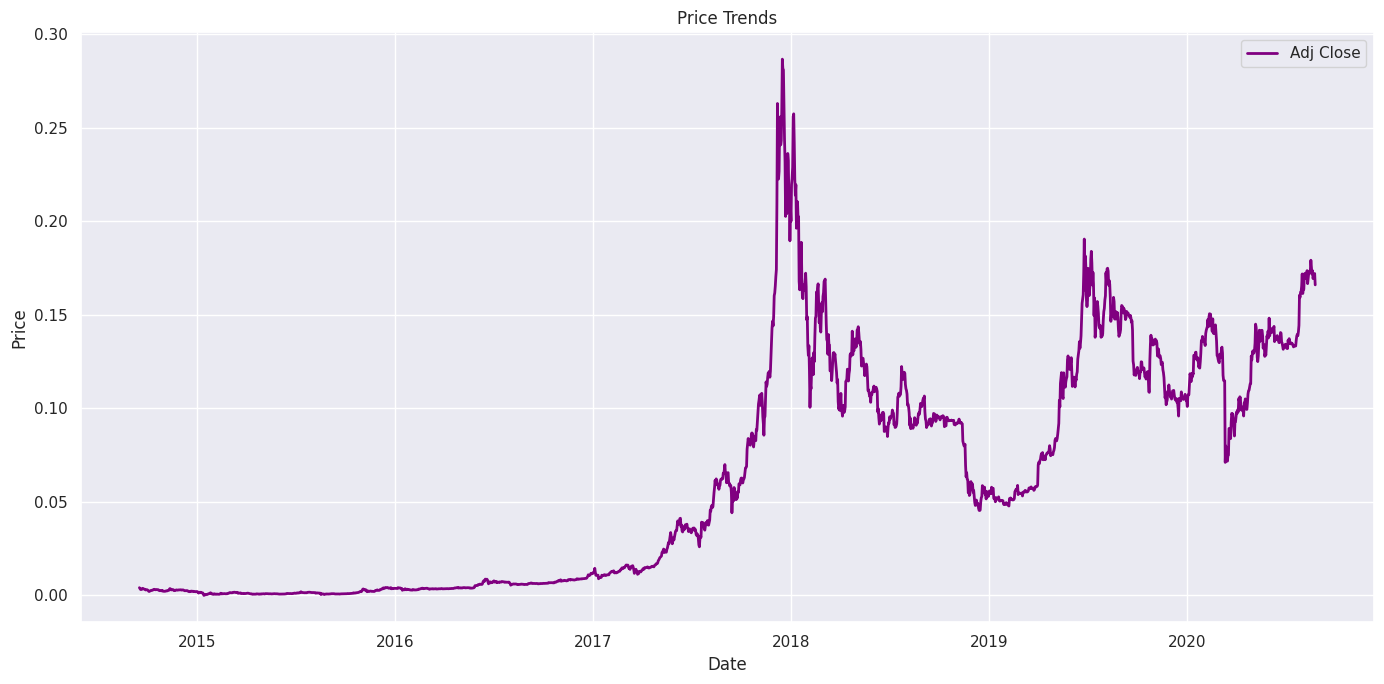

In [27]:
# Set the figure size
plt.figure(figsize=(14, 7))

# Plot prices against time
plt.plot(X_train.index, X_train['Adj Close'], label='Adj Close', color='purple', linewidth=2)

# Add title and labels
plt.title('Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

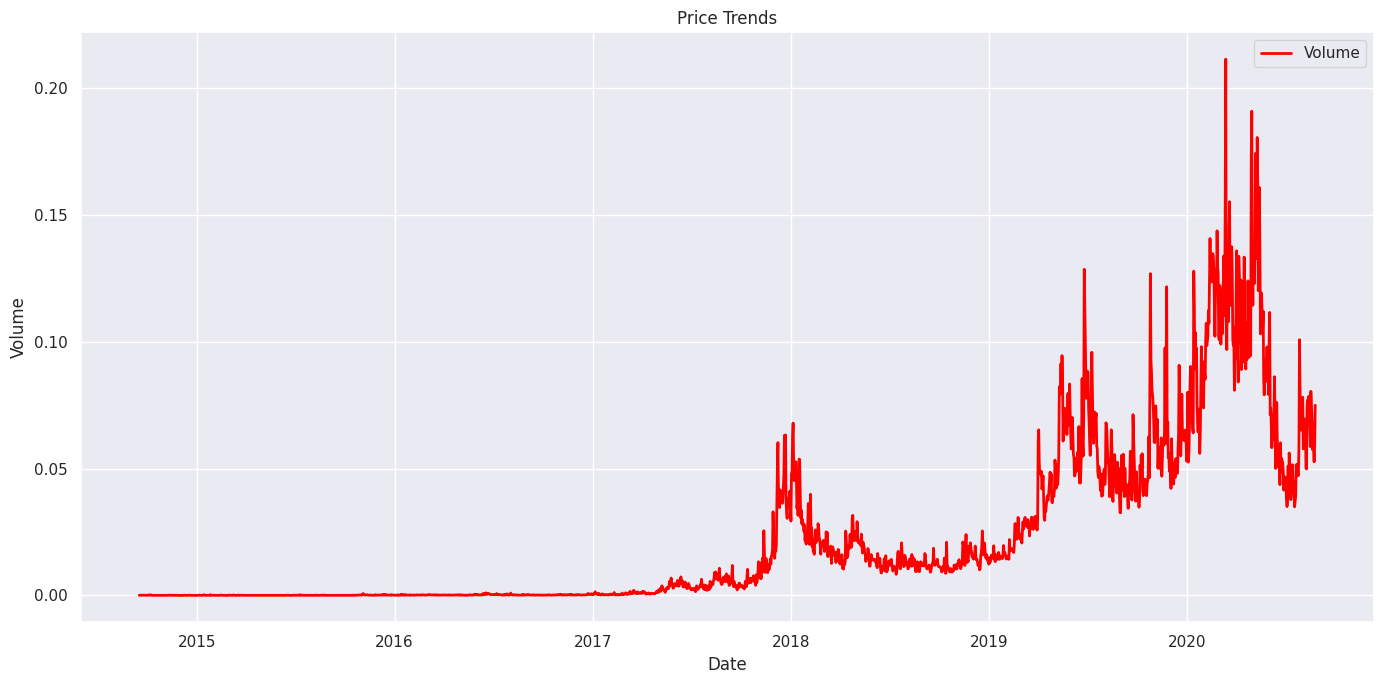

In [28]:
# Set the figure size
plt.figure(figsize=(14, 7))

# Plot volume against time
plt.plot(X_train.index, X_train['Volume'], label='Volume', color='red', linewidth=2)

# Add title and labels
plt.title('Price Trends')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

To analyse how the features are correlated with each other as well as the target, we will plot a correlation heatmap using Seaborn library. The code for the heatmap is shown below:

<Axes: >

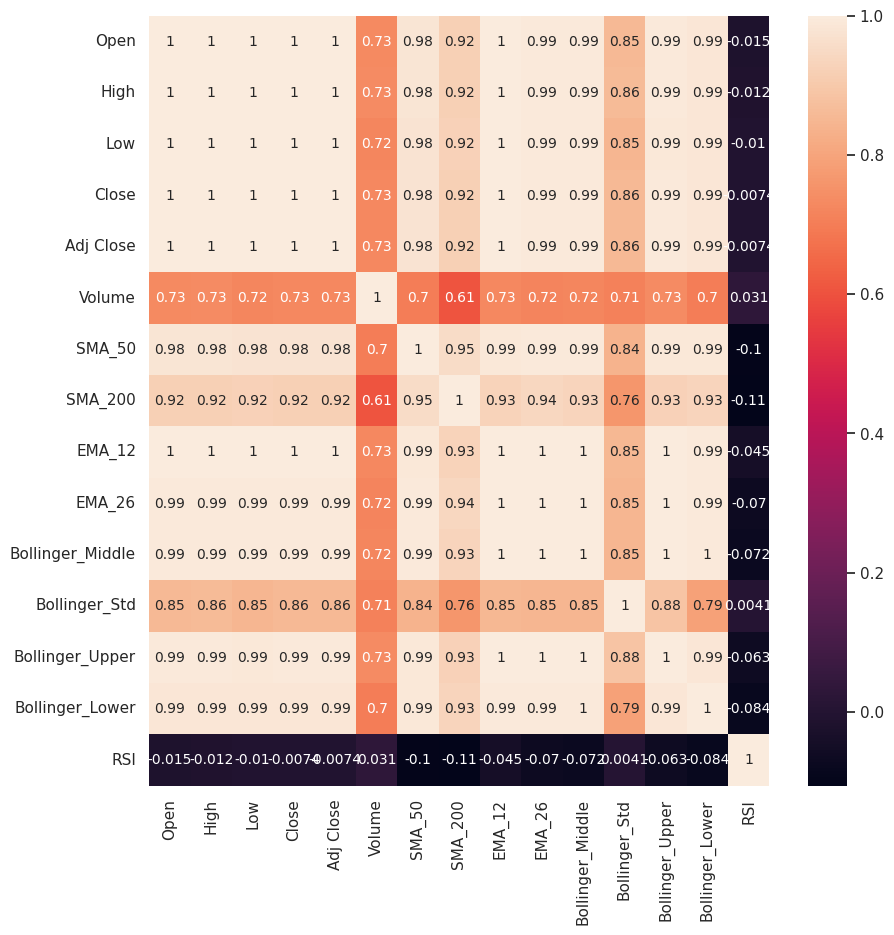

In [29]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(scaled_df.corr(numeric_only=True), annot=True, annot_kws={"fontsize":10}, ax=ax)

Clearly, from the plot above, we can see a strong postive correlation between nearly all the features, except for a weak negative correlation between RSI and other features. Below is a pairplot to visualize the correlation better through scatterplots.

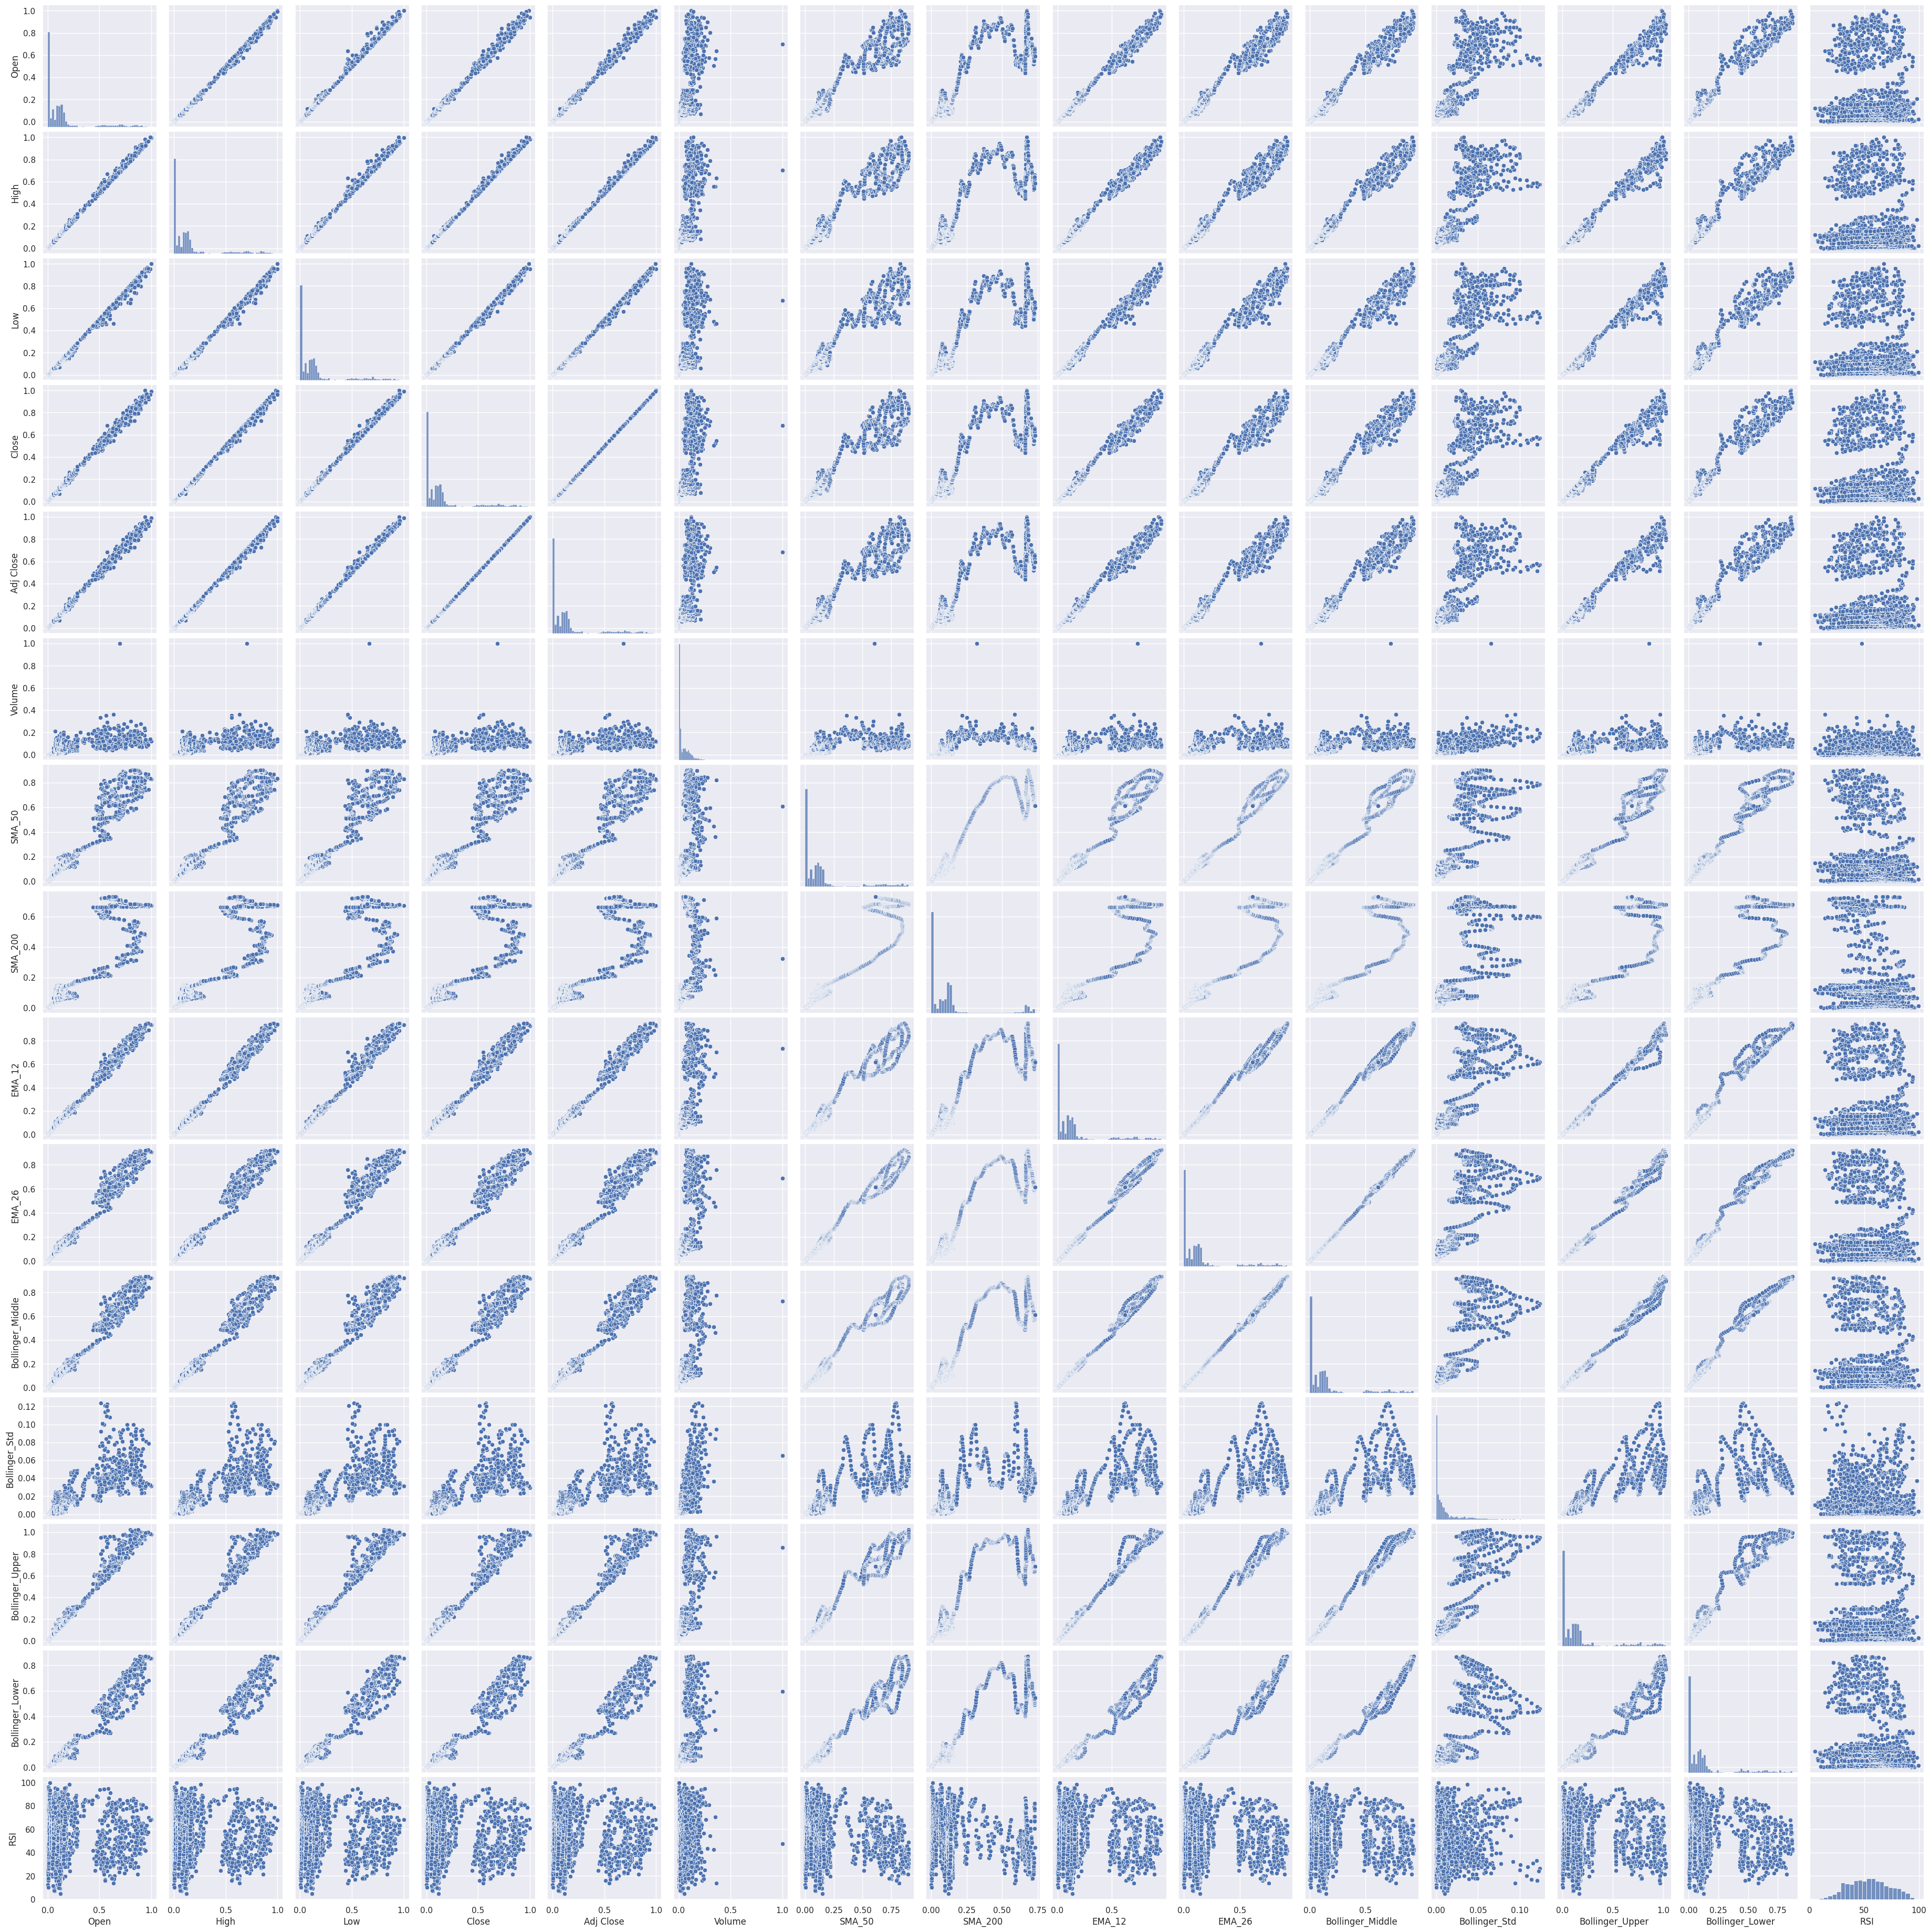

In [30]:
# Selecting numeric columns for pairplot
df_numeric = scaled_df.select_dtypes(exclude='object')
sns.pairplot(df_numeric)

# Model Training

Having completed data preprocessing and EDA, we can now proceed to build machine learning models using the train dataset (`X_train`) and evaluate the score metrics on the test dataset (`X_test`). For all the models that we build, we will train them on the train dataset and make predictions using the test dataset. Then, we shall evaluate its performance on the test dataset to help conclude which model best predicts the closing price.

## Linear Regression Model

We shall begin by training a basic linear regression model on our train dataset.

In [31]:
from sklearn.linear_model import LinearRegression

# Creating a linear regression model
model1 = LinearRegression()

# Training the linear regression model
model1.fit(X_train, y_train)

LinearRegression()

Having trained out linear regression model (`model1`), we shall make predictions on the test dataset and calculate the accuracy score.

In [32]:
# Making predictions on the test dataset
y_pred = model1.predict(X_test)
y_pred.shape

(543,)

In [33]:
# Calculating the accuracy score on the test dataset
model1.score(X_test, y_test)

1.0

## Random Forest Model

We shall now use random forest to build a model to make predictions.

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Creating a random forest model
model2 = RandomForestRegressor()

# Training the random forest model
model2.fit(X_train, y_train)

RandomForestRegressor()

Having trained the random forest model (`model2`), we shall make predictions and calculate the accuracy score on the train and test dataset.

In [35]:
# Calculating the score on the train dataset
model2.score(X_train, y_train)

0.9999812554784989

In [36]:
# Calculating the score on the test dataset
model2.score(X_test, y_test)

-1.6114056496988036

In [37]:
from sklearn.metrics import r2_score

y_pred = model2.predict(X_test)

r2_score(y_test, y_pred)

-1.6114056496988036

## Support Vector Machine

We shall now use Support Vector Regressor model to make predictions.

In [38]:
from sklearn.svm import SVR

# Creating an SVR model
model3 = SVR()

# Training the SVR model
model3.fit(X_train, y_train)

SVR()

In [39]:
# Calculating the score on the test dataset
model3.score(X_test, y_test)

-3.67467255796148

In [40]:
# Calculating the score on the train dataset
model3.score(X_train, y_train)

-0.3865400614361909

## XGBoost Model

We shall now train a model using Extreme Gradient Boosting (XGBoost).

In [41]:
from xgboost import XGBRegressor

# Creating an XGBoost model
model4 = XGBRegressor()

# Training the XGBoost model
model4.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
# Calculating the score on the test dataset
model4.score(X_test, y_test)

-1.8315740524856832

In [43]:
# Calculating the score on the train dataset
model4.score(X_train, y_train)

0.9999538458650628

## LSTM

We shall now train a model using Long Short-Term Memory (LSTM). We shall build a basic LSTM architecture of two layers of 50 units each. These LSTM layers help the model to remember "patterns" over time. The dense layers will then turn those patterns into actual predictions. Finally, we will compile the model so that it can be trained on the train dataset. In order to do this, we shall be using the TensorFlow library.

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model5 = Sequential()
model5.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model5.add(LSTM(units=50, return_sequences=False))
model5.add(Dense(25))
model5.add(Dense(1))  # Predict next price
model5.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
# Training the LSTM model
model5.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.8388e-05 - val_loss: 0.0020
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 5.2713e-05 - val_loss: 0.0027
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.5924e-05 - val_loss: 0.0083
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.3799e-05 - val_loss: 0.0229
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.6784e-05 - val_loss: 0.0374
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.2211e-05 - val_loss: 0.0511
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.9568e-05 - val_loss: 0.0293
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.0345e-05 - val_loss: 0.0621
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.0105e-05 - val_loss: 0.0621
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2591e-05 - val_loss: 0.0348
Epoch 12/20
68/68 ━━━━━

In [46]:
# Making predictions on the test dataset
y_pred5 = model5.predict(X_test)

# Inverse transform to get real price values
# predicted_prices = scaler.inverse_transform(y_pred5.reshape(-1, 1))
# actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


# Model Evaluation and Prediction

We begin our model evaluation on the test dataset using Root Mean Squared Error (RMSE) followed by Mean Absolute Error (MAE), Mean Squared Error (MSE) and $R^2$ score.

In [47]:
from sklearn.metrics import root_mean_squared_error

# Predicting on test data for all the trained models
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)
y_pred4 = model4.predict(X_test)

In [48]:
# Calculating RMSE for linear regression model
root_mean_squared_error(y_test, y_pred1)

4.089157312179954e-15

In [49]:
# Calculating RMSE for random forest model
root_mean_squared_error(y_test, y_pred2)

0.3814699916057949

In [50]:
# Calculating RMSE for SVR model
root_mean_squared_error(y_test, y_pred3)

0.5103860644891058

In [51]:
# Calculating RMSE for XGBoost model
root_mean_squared_error(y_test, y_pred4)

0.3972255473062686

In [52]:
# Calculating RMSE for LSTM model
root_mean_squared_error(y_test, y_pred5)

0.07323998197072862

In [53]:
# Importing necessary functions for model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
# Calculating MAE for linear regression model
mean_absolute_error(y_test, y_pred1)

3.3663986270160306e-15

In [55]:
# Calculating MAE for random forest model
mean_absolute_error(y_test, y_pred2)

0.3184808313446475

In [56]:
# Calculating MAE for SVR model
mean_absolute_error(y_test, y_pred3)

0.45717224882474244

In [57]:
# Calculating MAE for XGBoost model
mean_absolute_error(y_test, y_pred4)

0.3342019478520393

In [58]:
# Calculating MAE for LSTM model
mean_absolute_error(y_test, y_pred5)

0.061935065016760035

In [59]:
# Calculating MSE for linear regression model
mean_squared_error(y_test, y_pred1)

1.672120752375479e-29

In [60]:
# Calculating MSE for random forest model
mean_squared_error(y_test, y_pred2)

0.14551935449572526

In [61]:
# Calculating MSE for SVR model
mean_squared_error(y_test, y_pred3)

0.26049393482467775

In [62]:
# Calculating MSE for XGBoost model
mean_squared_error(y_test, y_pred4)

0.15778813543276463

In [63]:
# Calculating MSE for LSTM model
mean_squared_error(y_test, y_pred5)

0.005364094959072654

In [64]:
# Calculating r2_score for linear regression model
r2_score(y_test, y_pred1)

1.0

In [65]:
# Calculating r2_score for random forest model
r2_score(y_test, y_pred2)

-1.6114056496988036

In [66]:
# Calculating r2_score for SVR model
r2_score(y_test, y_pred3)

-3.67467255796148

In [67]:
# Calculating r2_score for XGBoost model
r2_score(y_test, y_pred4)

-1.8315740524856832

In [68]:
# Calculating r2_score for LSTM model
r2_score(y_test, y_pred5)

0.9037390735398384

## Summary
The table below summarizes the various scoring metrics on the test dataset.
| ML Model | RMSE | MAE | MSE | $R^2$ |
|----------|------|-----|-----|-------|
| Linear Regression| **4.089157312179954e-15**| **3.3663986270160306e-15**| **1.672120752375479e-29**| **1.0**|
| Random Forest|0.3814699916057949 | 0.3184808313446475| 0.14551935449572526| -1.6114056496988036|
| SVR | 0.5103860644891058| 0.45717224882474244| 0.26049393482467775| -3.67467255796148|
| XGBoost| 0.3972255473062686| 0.3342019478520393| 0.15778813543276463| -1.8315740524856832|
| LSTM| 0.07323998197072862| 0.061935065016760035| 0.005364094959072654| 0.9037390735398384|

Clearly, linear regression performs well on all the evaluation metrics, followed by LSTM. Ensemble methods such as random forest and XGBoost perform poorly, so does SVM model.

## Visualizing the Predictions

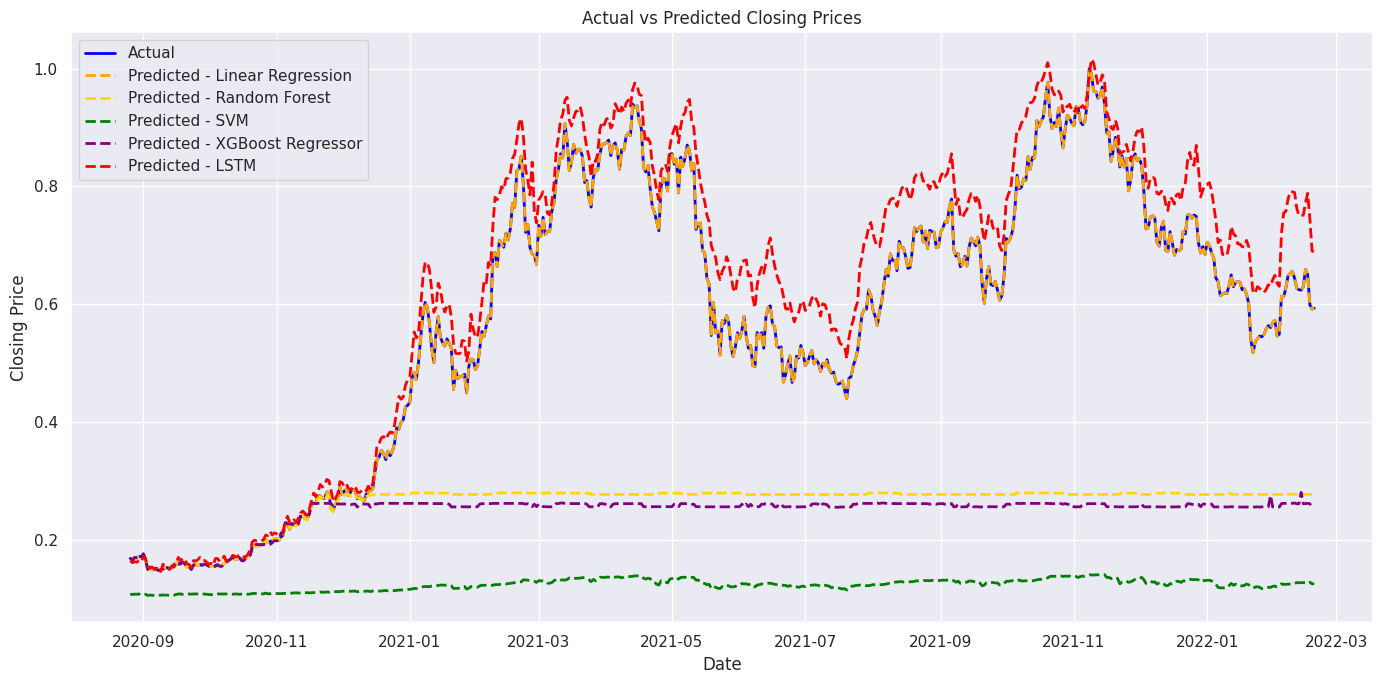

In [69]:
# Ensure the index is datetime (if not already)
X_test.index = pd.to_datetime(X_test.index)

# Set the figure size
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(X_test.index, y_test, label='Actual', color='blue', linewidth=2)

# Plot predicted values
plt.plot(X_test.index, y_pred1, label='Predicted - Linear Regression', color='orange', linestyle='--', linewidth=2)
plt.plot(X_test.index, y_pred2, label='Predicted - Random Forest', color='gold', linestyle='--', linewidth=2)
plt.plot(X_test.index, y_pred3, label='Predicted - SVM', color='green', linestyle='--', linewidth=2)
plt.plot(X_test.index, y_pred4, label='Predicted - XGBoost Regressor', color='purple', linestyle='--', linewidth=2)
plt.plot(X_test.index, y_pred5, label='Predicted - LSTM', color='red', linestyle='--', linewidth=2)

# Add title and labels
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion

So far we have trained five different machine learning models on the dataset, including one deep learning model, namely LSTM. We observed that on nearly all evaluation metrics, the linear regression model performed well, followed by the LSTM model. All other models performed poorly on the test dataset. The linear regression and LSTM models can help traders predict price trends based on past patterns.

Further improvements can include use of deep learning models such as improving the LSTM architecture, as well as using transformers for better accuracy on unseen future data.